In [1]:
%pip install langchain langgraph langchain-openai langchain-community langchain-tavily langchain-mcp-adapters mcp pywin32 -Uq

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['TAVILY_API_KEY'] = os.getenv("tavily_key")

In [11]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

### MCP Server 연동
- `http` 원격지의 MCP Server를 web 방식 호출
- `stdio` MCP Client system에서 MCP Server구동하는 경우

In [4]:
%pip install pywintypes

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pywintypes (from versions: none)
ERROR: No matching distribution found for pywintypes

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient

CONTEXT7_API_KEY = os.getenv('CONTEXT7_API_KEY')

mcp_client = MultiServerMCPClient({
    "docs-langchain": {
        "url" : "https://docs.langchain.com/mcp",
        "transport" : 'http'
    },
    "context7": {
        "url": "https://mcp.context7.com/mcp",
        "headers" : {
            "CONTEXT7_API_KEY": CONTEXT7_API_KEY
        },
        "transport": 'http'
    }
})

mcp_tools = await mcp_client.get_tools()
mcp_tools

[StructuredTool(name='SearchDocsByLangChain', description='Search across the Docs by LangChain knowledge base to find relevant information, code examples, API references, and guides. Use this tool when you need to answer questions about Docs by LangChain, find specific documentation, understand how features work, or locate implementation details. The search returns contextual content with titles and direct links to the documentation pages.', args_schema={'type': 'object', 'properties': {'query': {'type': 'string', 'description': 'Search query'}, 'apiReferenceOnly': {'type': 'boolean', 'description': 'Only return API reference docs'}, 'codeOnly': {'type': 'boolean', 'description': 'Only return code snippets'}}, 'required': ['query'], 'additionalProperties': False, '$schema': 'http://json-schema.org/draft-07/schema#'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x000001894FDE8680>),
 StructuredTool(name='resolve-li

In [13]:
# Tavily + MCP Tools를 LLM에 붙여서 챗봇 노드 구성
from langchain.chat_models import init_chat_model  # LangChain에서 채팅용 LLM 생성 함수

llm = init_chat_model('gpt-4.1-mini')              # 사용할 LLM 모델 초기화

tools = [tavily_tool] + mcp_tools                  # Tavily 검색 툴 + MCP에서 가져온 툴들을 하나의 리스트로 합침

llm_with_tools = llm.bind_tools(tools)             # LLM에 툴 사용 능력(툴 호출 권한) 부여


# 상태(state)를 받아 LLM 응답을 messages에 추가하는 노드 함수 (LangGraph에서 쓰는 패턴)
def chatbot(state):
    response = llm_with_tools.invoke(state['messages'])  # 지금까지 누적된 대화 메시지 전체를 넣어 LLM 실행
    return {'messages': [response]}                      # 새로 생성된 응답 메시지를 상태에 추가해서 다음 노드로 전달

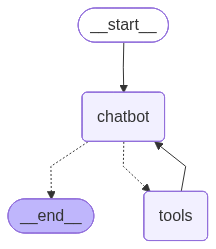

In [15]:
from langgraph.prebuilt import ToolNode, tools_condition   # 툴 실행 노드와 "툴 쓸지 말지" 분기 조건
from typing import TypedDict, Annotated, List              # 상태 타입 정의용
from langgraph.graph import add_messages, StateGraph, START, END  # 그래프와 메시지 누적 유틸

class State(TypedDict):
    messages: Annotated[List, add_messages]  # 대화 메시지를 계속 누적해서 저장하는 상태 필드

builder = StateGraph(State)                 # 상태 구조(State)를 사용하는 그래프 생성
tool_node = ToolNode(tools)                 # LLM이 요청한 툴을 실제로 실행해주는 노드

builder.add_node('chatbot', chatbot)        # LLM이 응답 생성하는 노드 등록
builder.add_node('tools', tool_node)        # 툴 실행 노드 등록

builder.add_edge(START, 'chatbot')          # 시작하면 먼저 chatbot(LLM) 호출

builder.add_conditional_edges('chatbot', tools_condition)  
# LLM 응답에 "툴 호출 필요" 신호가 있으면 tools 노드로,
# 없으면 대화 종료(END) 쪽으로 분기

builder.add_edge('tools', 'chatbot')        # 툴 실행 결과를 다시 LLM에 넣어 후속 응답 생성

graph = builder.compile()                   # 위에서 정의한 노드/엣지 구조를 실행 가능한 그래프로 컴파일

graph                                        # 완성된 LangGraph 객체 (에이전트 실행용)


In [20]:
user_query = '최근 원화-달러 환율은 어떻게 돼?'
state = {'messages':[('human',user_query)]}
response = await graph.ainvoke(state)
print(response['messages'][-1].content)

최근 원화-달러 환율은 약 1,456.62원 수준입니다. 추가로 궁금한 점 있으면 말씀해 주세요!


In [21]:
user_query = 'langchain v1.2에서 달라진 점은 뭐야?'
state = {'messages':[('human',user_query)]}
response = await graph.ainvoke(state)
print(response['messages'][-1].content)

LangChain v1.2에서 달라진 주요 내용은 다음과 같습니다:

1. 네임스페이스 단순화:
   - LangChain의 네임스페이스가 핵심 구성 요소에 집중하도록 단순화되었습니다.
   - 기존의 레거시 기능들은 새로운 패키지인 `langchain-classic`으로 이동되었습니다.

2. 새로운 에이전트 생성 방식:
   - `create_agent`라는 새로운 표준 인터페이스가 도입되었습니다.
   - 이는 이전의 `langgraph.prebuilt.create_react_agent`를 대체하며, 보다 간단한 인터페이스와 미들웨어를 통한 커스터마이징 가능성을 제공합니다.

3. 패키지 업그레이드 방법:
   - pip 또는 uv 패키지 관리자를 통해 쉽게 LangChain v1.x로 업그레이드할 수 있습니다.

4. Python에서의 임포트 변경:
   - 기존 `langchain` 패키지에서 제공되던 일부 모듈이 `langchain-classic` 패키지로 이전되었기 때문에, import 경로를 업데이트해야 합니다.

요약하면, v1.2는 LangChain의 구조를 더 간결하게 만들고 새롭고 개선된 에이전트 빌딩 방식을 도입하여 확장성과 사용 편의성을 높인 버전입니다. 필요에 따라 기존 코드를 `langchain-classic`으로 마이그레이션해야 합니다.


In [22]:
user_query = '파이썬 3.13에서 새롭게 바뀐 내용이 뭐야? context7 tool을 사용해 줘'
state = {'messages':[('human',user_query)]}
response = await graph.ainvoke(state)
print(response['messages'][-1].content)

파이썬 3.13에서 새롭게 바뀐 주요 내용은 다음과 같습니다:

1. itertools 모듈 개선:
   - combinations_with_replacement(중복 조합 생성)
   - compress(선택자 기반 iterable 필터링)
   - count 함수가 Fraction 등 커스텀 타입의 step 인자 지원

2. shutil 모듈의 새로운 아카이빙 기능:
   - shutil.make_archive()로 아카이브 생성
   - shutil.unpack_archive()로 압축 해제
   - shutil.get_archive_formats()로 지원 형식 나열
   - shutil.register_archive_format()로 사용자 정의 압축 형식 등록 가능

3. 해시 알고리즘 정보 접근:
   - hashlib.algorithms_guaranteed와 algorithms_available로 시스템에서 사용 가능한 해시 알고리즘 집합 조회

4. Python 가상 머신의 새로운 Tier 2 인터프리터 도입 예정:
   - Tier 2는 마이크로 명령어 형식의 새로운 인터프리터로 Python 3.13에서 도입
   - 기존 Tier 1 인터프리터와 다른 API와 명령어 집합을 가짐
   - JIT(copy-and-patch 기술 기반) 구현의 기초가 됨

이 외에도 다양한 성능 개선과 버그 수정이 포함되어 있습니다. 더 자세한 내용이나 특정 기능에 대해 알고 싶으면 알려주세요!
